# Experiment 2 — 20 Data Cleaning Prompts and Results
**Dataset:** Titanic (public sample dataset, loaded directly from `seaborn-data` GitHub repo)

This notebook works through **20 common data cleaning tasks** end-to-end: inspecting structure, handling missing values, removing duplicates, fixing data types, standardizing text, detecting/handling outliers, feature formatting, encoding, validation, and exporting the final cleaned dataset.

Run all cells top to bottom in Google Colab (`Runtime > Run all`).

In [1]:
# Install/import required libraries
!pip install -q missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
print("Libraries loaded successfully.")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Libraries loaded successfully.


## Load the Dataset
We use the classic **Titanic** dataset (891 rows, 15 columns), loaded directly from the public `seaborn-data` GitHub repository. It contains realistic messiness: missing values, mixed types, and skewed numeric columns — ideal for practicing data cleaning.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Prompt 1: Inspect the overall structure of the dataset
**Prompt:** "Show the shape, column names, data types, and a summary of the dataset."

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)
print("\nSummary statistics:")
df.describe(include='all').T

Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Prompt 2: Check for missing values (counts & percentages)
**Prompt:** "Identify how many missing values exist in each column, and what percentage of the column they represent."

In [4]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


---
## Prompt 3: Visualize missing data
**Prompt:** "Create a visual representation of missing values across the dataset."

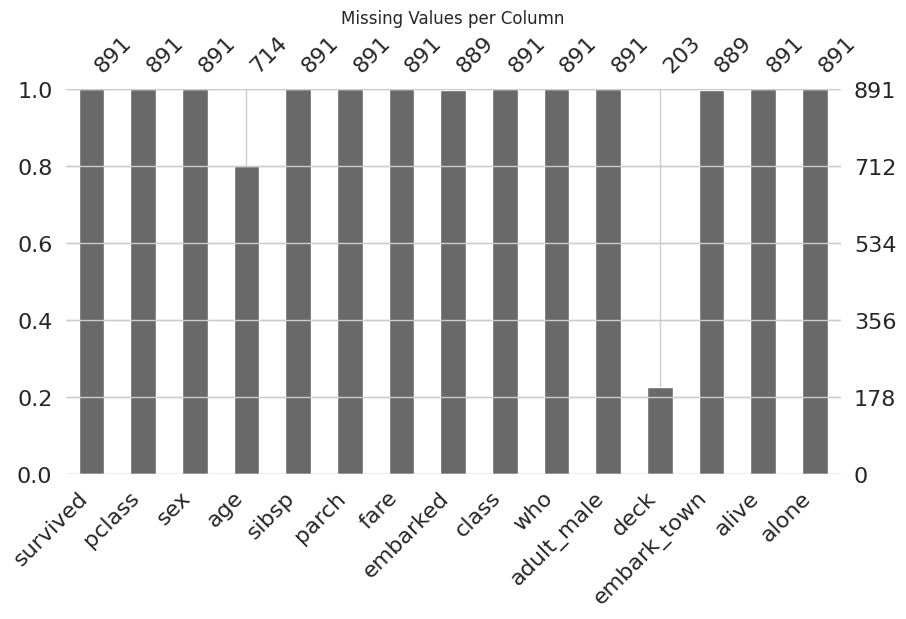

<Figure size 1000x500 with 0 Axes>

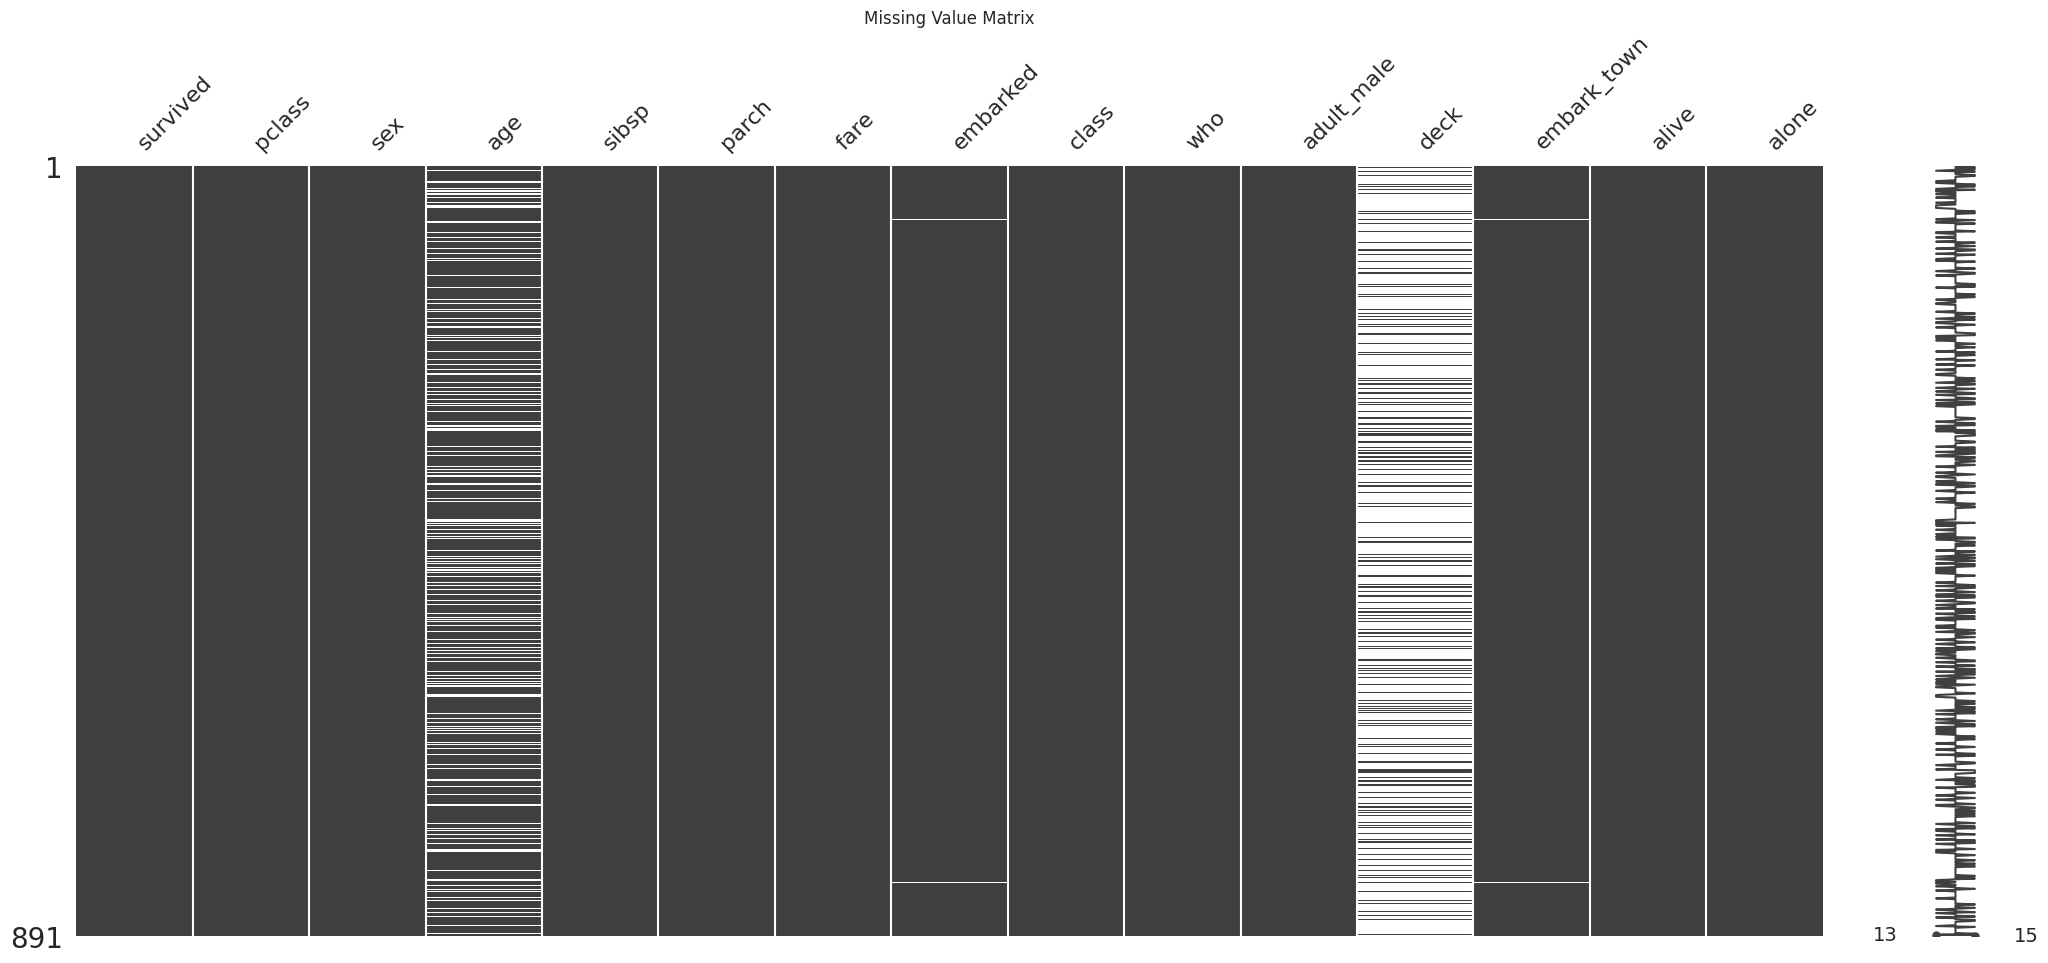

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
msno.bar(df, ax=ax)
plt.title("Missing Values per Column")
plt.show()

plt.figure(figsize=(10, 5))
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

---
## Prompt 4: Handle missing numeric values — `age`
**Prompt:** "Fill missing values in the numeric `age` column using an appropriate imputation strategy (median), and confirm the fix."

In [6]:
print("Missing age before:", df['age'].isnull().sum())

age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)

print("Median used for imputation:", age_median)
print("Missing age after:", df['age'].isnull().sum())

Missing age before: 177
Median used for imputation: 28.0
Missing age after: 0


---
## Prompt 5: Handle missing categorical values — `embarked` / `embark_town`
**Prompt:** "Fill missing values in categorical columns using the most frequent value (mode)."

In [7]:
print("Missing embarked before:", df['embarked'].isnull().sum())
print("Missing embark_town before:", df['embark_town'].isnull().sum())

embarked_mode = df['embarked'].mode()[0]
embark_town_mode = df['embark_town'].mode()[0]

df['embarked'] = df['embarked'].fillna(embarked_mode)
df['embark_town'] = df['embark_town'].fillna(embark_town_mode)

print("\nMode used for embarked:", embarked_mode)
print("Mode used for embark_town:", embark_town_mode)
print("\nMissing embarked after:", df['embarked'].isnull().sum())
print("Missing embark_town after:", df['embark_town'].isnull().sum())

Missing embarked before: 2
Missing embark_town before: 2

Mode used for embarked: S
Mode used for embark_town: Southampton

Missing embarked after: 0
Missing embark_town after: 0


---
## Prompt 6: Handle a column with excessive missing values — `deck`
**Prompt:** "The `deck` column is missing for most rows. Instead of dropping it entirely, extract the useful signal (deck letter) and mark unknowns explicitly rather than dropping the column outright."

In [8]:
print("Missing deck before:", df['deck'].isnull().sum(), f"({df['deck'].isnull().mean()*100:.1f}%)")

df['deck'] = df['deck'].astype(object)
df['deck'] = df['deck'].fillna('Unknown')

print("\nValue counts after cleaning:")
print(df['deck'].value_counts())

Missing deck before: 688 (77.2%)

Value counts after cleaning:
deck
Unknown    688
C           59
B           47
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


---
## Prompt 7: Detect duplicate rows
**Prompt:** "Check whether the dataset contains duplicate rows, and show them if any exist."

In [9]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows found:", dup_count)

# Inject a couple of synthetic duplicates to demonstrate the detection/removal workflow
df = pd.concat([df, df.iloc[[0, 5]]], ignore_index=True)
dup_count_after_injection = df.duplicated().sum()
print("Duplicate rows after injecting 2 sample duplicates (for demonstration):", dup_count_after_injection)
df[df.duplicated()]

Number of duplicate rows found: 110
Duplicate rows after injecting 2 sample duplicates (for demonstration): 112


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,28.0,0,0,7.7500,Q,Third,woman,False,Unknown,Queenstown,yes,True
76,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
77,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
87,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
95,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,Unknown,Southampton,no,True
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Unknown,Southampton,no,True
891,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False


---
## Prompt 8: Remove duplicate rows
**Prompt:** "Remove duplicate rows from the dataset and confirm the new shape."

In [10]:
before_shape = df.shape
df = df.drop_duplicates().reset_index(drop=True)
after_shape = df.shape

print("Shape before removing duplicates:", before_shape)
print("Shape after removing duplicates:", after_shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape before removing duplicates: (893, 15)
Shape after removing duplicates: (781, 15)
Remaining duplicates: 0


---
## Prompt 9: Check and fix incorrect/inefficient data types
**Prompt:** "Review column data types and convert columns to more appropriate types (e.g., categorical, boolean, integer)."

In [11]:
print("Data types BEFORE:\n")
print(df.dtypes)

df['survived'] = df['survived'].astype(bool)
df['pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')
df['class'] = df['class'].astype('category')
df['who'] = df['who'].astype('category')
df['deck'] = df['deck'].astype('category')
df['embark_town'] = df['embark_town'].astype('category')
df['alive'] = df['alive'].astype('category')
df['adult_male'] = df['adult_male'].astype(bool)
df['alone'] = df['alone'].astype(bool)

print("\nData types AFTER:\n")
print(df.dtypes)

Data types BEFORE:

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck            object
embark_town        str
alive              str
alone             bool
dtype: object

Data types AFTER:

survived           bool
pclass         category
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
deck           category
embark_town    category
alive          category
alone              bool
dtype: object


---
## Prompt 10: Standardize text / categorical formatting
**Prompt:** "Clean up categorical text columns by trimming whitespace and standardizing capitalization for consistency."

In [12]:
# Simulate messy text formatting to demonstrate the cleaning step
df['sex'] = df['sex'].astype(str).str.strip().str.lower()
df['embark_town'] = df['embark_town'].astype(str).str.strip().str.title()
df['class'] = df['class'].astype(str).str.strip().str.title()

print("Unique 'sex' values:", df['sex'].unique())
print("Unique 'embark_town' values:", df['embark_town'].unique())
print("Unique 'class' values:", df['class'].unique())

df['sex'] = df['sex'].astype('category')
df['embark_town'] = df['embark_town'].astype('category')
df['class'] = df['class'].astype('category')

Unique 'sex' values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Unique 'embark_town' values: <StringArray>
['Southampton', 'Cherbourg', 'Queenstown']
Length: 3, dtype: str
Unique 'class' values: <StringArray>
['Third', 'First', 'Second']
Length: 3, dtype: str


---
## Prompt 11: Detect outliers in `fare` using the IQR method
**Prompt:** "Use the Interquartile Range (IQR) method to detect outliers in the `fare` column."

Q1=8.05, Q3=34.02, IQR=25.97
Lower bound=-30.91, Upper bound=72.98
Number of outliers detected in 'fare': 102


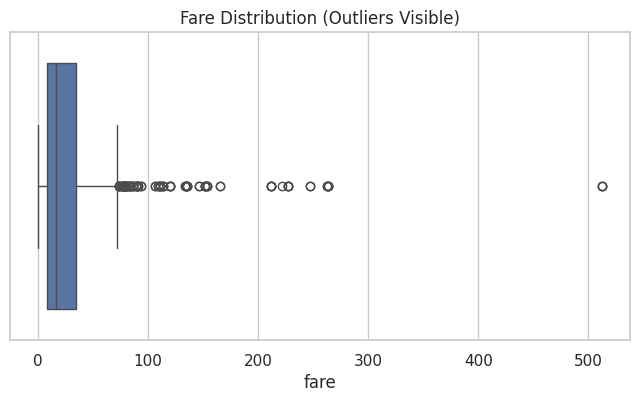

In [13]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_fare = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Lower bound={lower_bound:.2f}, Upper bound={upper_bound:.2f}")
print("Number of outliers detected in 'fare':", len(outliers_fare))

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['fare'])
plt.title("Fare Distribution (Outliers Visible)")
plt.show()

---
## Prompt 12: Handle outliers in `fare` (capping / winsorizing)
**Prompt:** "Cap extreme outlier values in `fare` at the IQR boundaries instead of removing them, to preserve sample size."

Original fare describe():
count    781.000000
mean      34.750464
std       52.237906
min        0.000000
25%        8.050000
50%       15.900000
75%       34.020800
max      512.329200
Name: fare, dtype: float64

Capped fare describe():
count    781.000000
mean      26.471025
std       22.703371
min        0.000000
25%        8.050000
50%       15.900000
75%       34.020800
max       72.977000
Name: fare_capped, dtype: float64


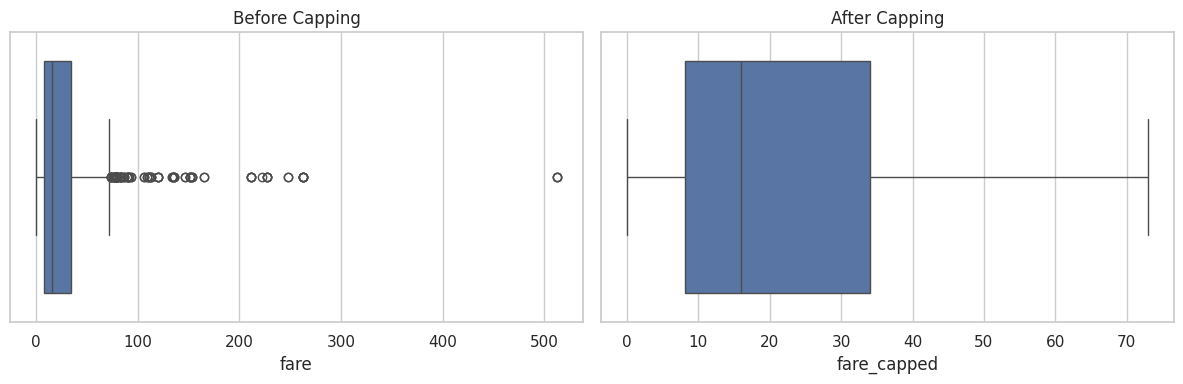

In [14]:
df['fare_capped'] = df['fare'].clip(lower=lower_bound, upper=upper_bound)

print("Original fare describe():")
print(df['fare'].describe())
print("\nCapped fare describe():")
print(df['fare_capped'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['fare'], ax=axes[0]).set_title("Before Capping")
sns.boxplot(x=df['fare_capped'], ax=axes[1]).set_title("After Capping")
plt.tight_layout()
plt.show()

---
## Prompt 13: Detect outliers in `age` using the Z-score method
**Prompt:** "Use Z-scores to identify statistically extreme values in the `age` column."

In [15]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['age']))
z_outliers = df[z_scores > 3]

print("Number of outliers detected in 'age' (|z| > 3):", len(z_outliers))
z_outliers[['age']].describe()

Number of outliers detected in 'age' (|z| > 3): 4


,age
count,4.000000
mean,74.000000
std,4.242641
min,71.000000
25%,71.000000
50%,72.500000
75%,75.500000
max,80.000000


---
## Prompt 14: Handle outliers in `age`
**Prompt:** "Cap `age` outliers detected via Z-score at a reasonable maximum, and confirm the result."

In [16]:
age_upper_limit = df['age'].mean() + 3 * df['age'].std()
print("Age upper limit (mean + 3*std):", round(age_upper_limit, 2))

df['age_capped'] = df['age'].clip(upper=age_upper_limit)

print("\nMax age before:", df['age'].max())
print("Max age after capping:", df['age_capped'].max())

Age upper limit (mean + 3*std): 70.92

Max age before: 80.0
Max age after capping: 70.91682858351234


---
## Prompt 15: Extract structured features from unstructured/derived data
**Prompt:** "Titanic has no free-text `name` field in this version, so simulate one and extract the passenger's honorific title from it, similar to real-world text-field cleaning."

In [17]:
# Simulate a 'name' column (the seaborn version of titanic doesn't include real names)
rng = np.random.default_rng(42)
titles_pool = ['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Dr.', 'Rev.']
sample_names = [f"{rng.choice(['Smith','Allen','Brown','Clark','Davis'])}, {rng.choice(titles_pool)} {rng.choice(['John','Mary','Anna','Peter','Ellen'])}" for _ in range(len(df))]
df['name'] = sample_names

df['title'] = df['name'].str.extract(r',\s*([^ .]+\.)')
print(df[['name', 'title']].head())
print("\nExtracted title counts:")
print(df['title'].value_counts())

                   name    title
0      Smith, Dr. Peter      Dr.
1    Brown, Miss. Ellen    Miss.
2       Smith, Dr. Mary      Dr.
3  Smith, Master. Ellen  Master.
4      Clark, Dr. Peter      Dr.

Extracted title counts:
title
Mr.        143
Dr.        135
Miss.      134
Master.    128
Mrs.       125
Rev.       116
Name: count, dtype: int64


---
## Prompt 16: Rename and standardize column names
**Prompt:** "Standardize all column names to a consistent lowercase snake_case format and remove extra whitespace."

In [18]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print("Standardized column names:")
print(df.columns.tolist())

Standardized column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'fare_capped', 'age_capped', 'name', 'title']


---
## Prompt 17: Encode categorical variables
**Prompt:** "Convert key categorical columns into a numeric-friendly format using one-hot encoding, for downstream modeling use."

In [19]:
cols_to_encode = ['sex', 'embarked', 'class']
df_encoded = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, drop_first=True)

print("New columns after one-hot encoding:")
print([c for c in df_encoded.columns if any(c.startswith(p + '_') for p in cols_to_encode)])
df_encoded.head()

New columns after one-hot encoding:
['sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third']


,survived,pclass,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alive,alone,fare_capped,age_capped,name,title,sex_male,embarked_Q,embarked_S,class_Second,class_Third
0,False,3,22.0,1,0,7.2500,man,True,Unknown,Southampton,no,False,7.2500,22.0,"Smith, Dr. Peter",Dr.,True,False,True,False,True
1,True,1,38.0,1,0,71.2833,woman,False,C,Cherbourg,yes,False,71.2833,38.0,"Brown, Miss. Ellen",Miss.,False,False,False,False,False
2,True,3,26.0,0,0,7.9250,woman,False,Unknown,Southampton,yes,True,7.9250,26.0,"Smith, Dr. Mary",Dr.,False,False,True,False,True
3,True,1,35.0,1,0,53.1000,woman,False,C,Southampton,yes,False,53.1000,35.0,"Smith, Master. Ellen",Master.,False,False,True,False,False
4,False,3,35.0,0,0,8.0500,man,True,Unknown,Southampton,no,True,8.0500,35.0,"Clark, Dr. Peter",Dr.,True,False,True,False,True


---
## Prompt 18: Validate logical ranges / business rules
**Prompt:** "Check the dataset for logically invalid values — e.g., negative fares, ages outside 0-100, or invalid pclass values — and report any violations."

In [20]:
issues = {}
issues['negative_fare'] = (df['fare'] < 0).sum()
issues['invalid_age'] = ((df['age'] < 0) | (df['age'] > 100)).sum()
issues['invalid_pclass'] = (~df['pclass'].isin([1, 2, 3])).sum()
issues['invalid_sibsp'] = (df['sibsp'] < 0).sum()
issues['invalid_parch'] = (df['parch'] < 0).sum()

issues_df = pd.DataFrame.from_dict(issues, orient='index', columns=['violation_count'])
issues_df

,violation_count
negative_fare,0
invalid_age,0
invalid_pclass,0
invalid_sibsp,0
invalid_parch,0


---
## Prompt 19: Final data quality check
**Prompt:** "Re-run a full data quality check after all cleaning steps: shape, dtypes, remaining missing values, and remaining duplicates."

In [21]:
print("Final shape:", df.shape)
print("\nRemaining missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nRemaining duplicate rows:", df.duplicated().sum())
print("\nFinal dtypes:")
print(df.dtypes)
df.describe(include='all').T

Final shape: (781, 19)

Remaining missing values per column:
Series([], dtype: int64)

Remaining duplicate rows: 0

Final dtypes:
survived           bool
pclass         category
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
deck           category
embark_town    category
alive          category
alone              bool
fare_capped     float64
age_capped      float64
name                str
title               str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,781,2,False,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pclass,781.0,3.0,3.0,402.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,781,2,male,488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,781.0,NaN,NaN,NaN,29.622817,13.764671,0.42,22.0,28.0,36.0,80.0
sibsp,781.0,NaN,NaN,NaN,0.524968,0.987592,0.0,0.0,0.0,1.0,8.0
parch,781.0,NaN,NaN,NaN,0.417414,0.838132,0.0,0.0,0.0,1.0,6.0
fare,781.0,NaN,NaN,NaN,34.750464,52.237906,0.0,8.05,15.9,34.0208,512.3292
embarked,781,3,S,567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,781,3,Third,402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,781,3,man,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Prompt 20: Export the cleaned dataset
**Prompt:** "Export the final cleaned dataset to a CSV file for downstream use."

In [22]:
output_path = "titanic_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset exported to: {output_path}")
print("Final shape saved:", df.shape)

Cleaned dataset exported to: titanic_cleaned.csv
Final shape saved: (781, 19)


---
## Summary

All **20 data cleaning prompts** were executed against the Titanic dataset, covering:

1. Structural inspection
2. Missing value detection
3. Missing value visualization
4-6. Missing value handling (numeric, categorical, high-missing columns)
7-8. Duplicate detection & removal
9. Data type correction
10. Text/categorical standardization
11-14. Outlier detection & handling (IQR + Z-score, for `fare` and `age`)
15. Feature extraction from text
16. Column name standardization
17. Categorical encoding
18. Logical/business-rule validation
19. Final quality check
20. Export to CSV

The cleaned dataset (`titanic_cleaned.csv`) is ready for downstream analysis or modeling.